# Dataset State Matrix

Two metrics are computed per cell type per dataset, measuring different failure modes.

---

## Normalized Shannon Entropy (fragmentation)

Asks: **how spread is this cell type across Leiden clusters?**

```
Cell type: B cell

Low entropy (good)          High entropy (fragmented)
───────────────────         ───────────────────────────
cluster 0 ██████████ 90%    cluster 0 ███ 20%
cluster 1 █ 10%             cluster 1 ███ 18%
                            cluster 2 ███ 17%
                            cluster 3 ███ 17%
                            cluster 4 ███ 15%
                            cluster 5 ██  13%

entropy ≈ 0.14              entropy ≈ 0.99
```

Range: `[0, 1]`. High value means the cell type bleeds across many clusters -- possibly a sign of poor resolution, annotation noise, or a heterogeneous population.

---

## KL Divergence (coherence)

Asks: **does this cell type concentrate in clusters more than chance would predict?**

```
Cell type: B cell   Global cluster distribution: all clusters roughly equal (17%)

Low KL divergence (bad)             High KL divergence (good)
─────────────────────────────────   ────────────────────────────────
cluster 0: p(c|B) 20% vs p(c) 17%  cluster 3: p(c|B) 85% vs p(c) 17%
cluster 1: p(c|B) 18% vs p(c) 17%  cluster 0: p(c|B) 15% vs p(c) 17%
...B cells match global dist...     ...B cells heavily prefer cluster 3...

KL ≈ 0.06 bits                      KL ≈ 1.2 bits
```

Range: `[0, ∞)` in bits. Computed as D_KL(p(cluster|cell_type) || p(cluster)). Near zero means the cell type mirrors the global distribution; higher means it concentrates distinctively.

---

## Reading them together

| Normalized Shannon Entropy | KL Divergence | Interpretation |
|---------|-------------|----------------|
| Low     | High        | Tight, coherent mapping -- ideal |
| Low     | Low         | Concentrated in a cluster, but that cluster is dominant globally -- not distinctive |
| High    | High        | Spread across clusters that are all globally rare -- unusual |
| High    | Low         | Fragmented and indistinct -- worst case |

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import scanpy as sc
from IPython.display import display
from scipy.stats import entropy as scipy_entropy

In [2]:
a1 = sc.read_h5ad(
    Path().resolve().parent / "output/clustering/data/SRX12366723_clustered.h5ad"
)
a2 = sc.read_h5ad(
    Path().resolve().parent / "output/clustering/data/SRX13198730_clustered.h5ad"
)
a3 = sc.read_h5ad(
    Path().resolve().parent / "output/clustering/data/SRX17412841_clustered.h5ad"
)

datasets = {"SRX12366723": a1, "SRX13198730": a2, "SRX17412841": a3}

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/inf-33-2025/Nygen_Project/output/clustering/data/SRX12366723_clustered.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

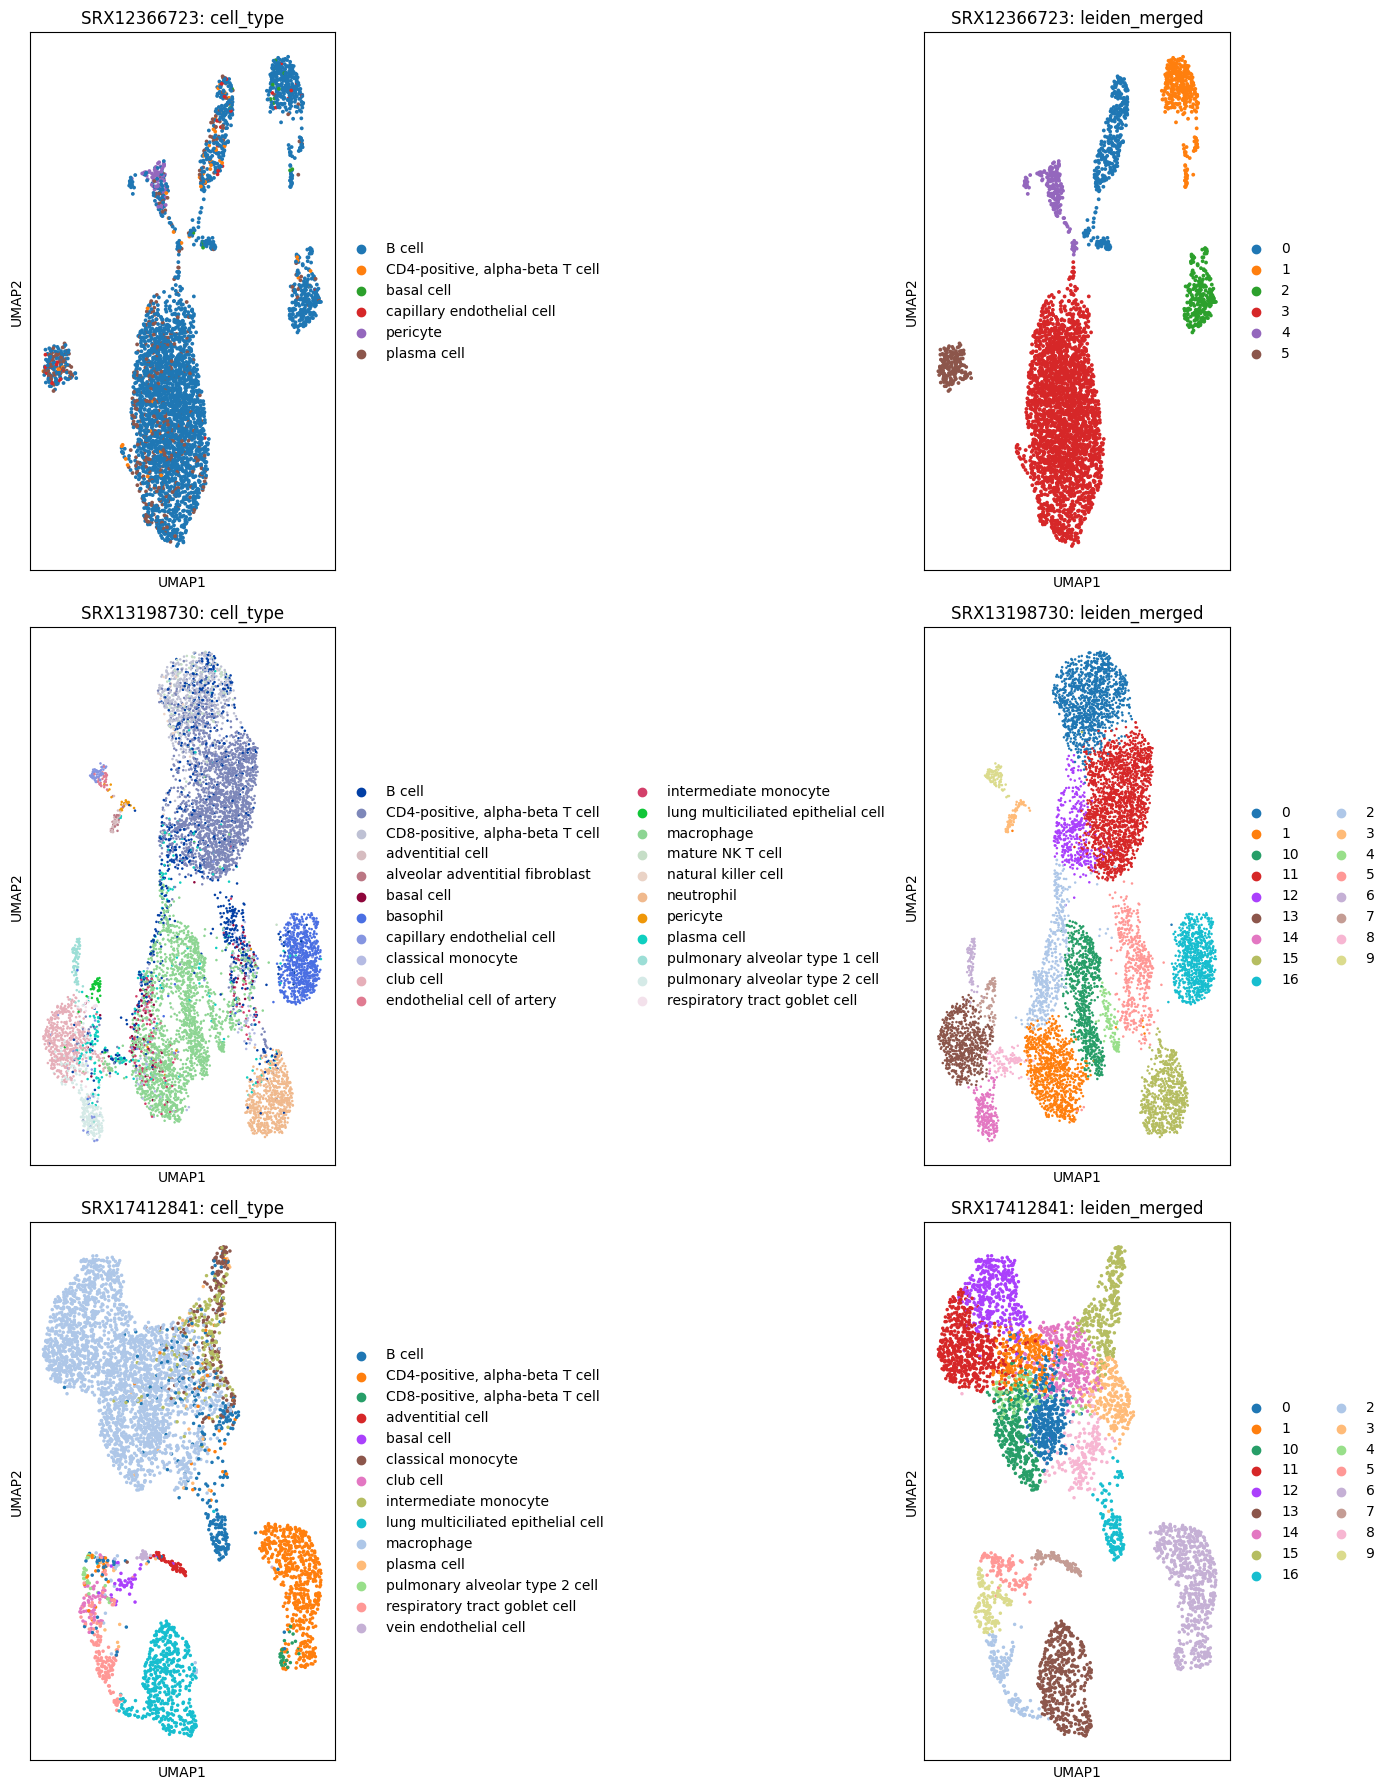

In [ ]:
fig, axs = plt.subplots(len(datasets), 2, figsize=(14, 6 * len(datasets)))

for row, (srx, a) in enumerate(datasets.items()):
    sc.pl.umap(a, color="cell_type", ax=axs[row, 0], show=False, title=f"{srx}: cell_type")
    sc.pl.umap(a, color="leiden_merged", ax=axs[row, 1], show=False, title=f"{srx}: leiden_merged")

plt.tight_layout()
plt.show()

In [ ]:
nse_rows = {}
kld_rows = {}

for srx, a in datasets.items():
    global_labels = a.obs["leiden_merged"]
    all_clusters = global_labels.cat.categories
    q = global_labels.value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    nse_row = {}  # normalized shannon entropy
    kld_row = {}  # kl divergence
    for cell_type in a.obs["cell_type"].unique():
        labels = a.obs[a.obs["cell_type"] == cell_type]["leiden_merged"]
        counts = labels.value_counts(normalize=True)
        counts = counts[counts > 0]
        nse_row[cell_type] = scipy_entropy(counts, base=2) / np.log2(len(counts)) if len(counts) > 1 else 0.0
        p = labels.value_counts(normalize=True).reindex(all_clusters, fill_value=0)
        kld_row[cell_type] = scipy_entropy(p, q, base=2)
    nse_rows[srx] = nse_row
    kld_rows[srx] = kld_row

nse_df = pd.DataFrame(nse_rows).T
nse_df.index.name = "srx"
kld_df = pd.DataFrame(kld_rows).T
kld_df.index.name = "srx"

In [ ]:
def plot_cell_type_metrics(
    summary_df: pd.DataFrame,
    sort_by: str = "normalized_shannon_entropy_mean",
    figsize: tuple[int, int] = (14, 10),
) -> None:
    """Plot entropy and KL divergence per cell type as two separate horizontal bar charts.

    Entropy is shown on its natural [0, 1] scale. KL divergence is shown on its raw scale in bits.
    Each chart is sorted by sort_by independently.

    Args:
        summary_df: DataFrame with columns normalized_shannon_entropy_mean and kl_divergence_mean, indexed by cell type.
        sort_by: column to sort rows by before plotting.
        figsize: matplotlib figure size.
    Returns:
        None
    """
    sorted_df = summary_df.sort_values(sort_by)
    labels = sorted_df.index.tolist()
    y = np.arange(len(labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    ax1.barh(y, sorted_df["normalized_shannon_entropy_mean"], color="steelblue")
    ax1.set_yticks(y)
    ax1.set_yticklabels(labels)
    ax1.set_xlabel("normalized Shannon entropy [0, 1]")
    ax1.set_title("Normalized Shannon Entropy (↑ = more fragmented)")

    ax2.barh(y, sorted_df["kl_divergence_mean"], color="darkorange")
    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlabel("KL divergence (bits)")
    ax2.set_title("KL Divergence (↑ = more coherent)")

    plt.tight_layout()
    plt.show()

Normalized Shannon Entropy (↑ = more fragmented)


,B cell,plasma cell,"CD4-positive, alpha-beta T cell",pericyte,capillary endothelial cell,basal cell,macrophage,mature NK T cell,club cell,neutrophil,...,pulmonary alveolar type 2 cell,classical monocyte,intermediate monocyte,pulmonary alveolar type 1 cell,alveolar adventitial fibroblast,lung multiciliated epithelial cell,natural killer cell,endothelial cell of artery,respiratory tract goblet cell,vein endothelial cell
srx,,,,,,,,,,,,,,,,,,,,,
SRX12366723,0.598,0.611,0.843,0.000,0.800,0.971,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SRX13198730,0.743,0.906,0.363,0.686,0.719,0.695,0.649,0.288,0.147,0.0,...,0.874,0.596,0.636,0.252,0.335,0.253,0.258,0.401,0.634,NaN
SRX17412841,0.715,0.898,0.195,NaN,NaN,0.576,0.750,NaN,0.129,NaN,...,0.722,0.480,0.625,NaN,NaN,0.202,NaN,NaN,0.695,0.25


KL Divergence (↑ = more coherent)


,B cell,plasma cell,"CD4-positive, alpha-beta T cell",pericyte,capillary endothelial cell,basal cell,macrophage,mature NK T cell,club cell,neutrophil,...,pulmonary alveolar type 2 cell,classical monocyte,intermediate monocyte,pulmonary alveolar type 1 cell,alveolar adventitial fibroblast,lung multiciliated epithelial cell,natural killer cell,endothelial cell of artery,respiratory tract goblet cell,vein endothelial cell
srx,,,,,,,,,,,,,,,,,,,,,
SRX12366723,0.015,0.168,0.949,4.377,1.929,2.511,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SRX13198730,0.823,0.918,1.379,4.849,2.886,2.020,1.738,2.282,3.593,3.713,...,3.968,2.508,2.119,5.955,6.11,6.080,2.744,5.294,4.588,NaN
SRX17412841,1.921,1.503,2.518,NaN,NaN,4.542,0.688,NaN,5.048,NaN,...,4.513,2.558,2.229,NaN,NaN,3.151,NaN,NaN,4.003,5.214


Cross-dataset summary (mean per cell type)


,n_datasets,normalized_shannon_entropy_mean,kl_divergence_mean
cell_type,,,
plasma cell,3,0.805,0.863
pulmonary alveolar type 2 cell,2,0.798,4.240
capillary endothelial cell,2,0.759,2.407
basal cell,3,0.747,3.024
macrophage,2,0.699,1.213
B cell,3,0.685,0.920
respiratory tract goblet cell,2,0.664,4.296
intermediate monocyte,2,0.631,2.174
classical monocyte,2,0.538,2.533


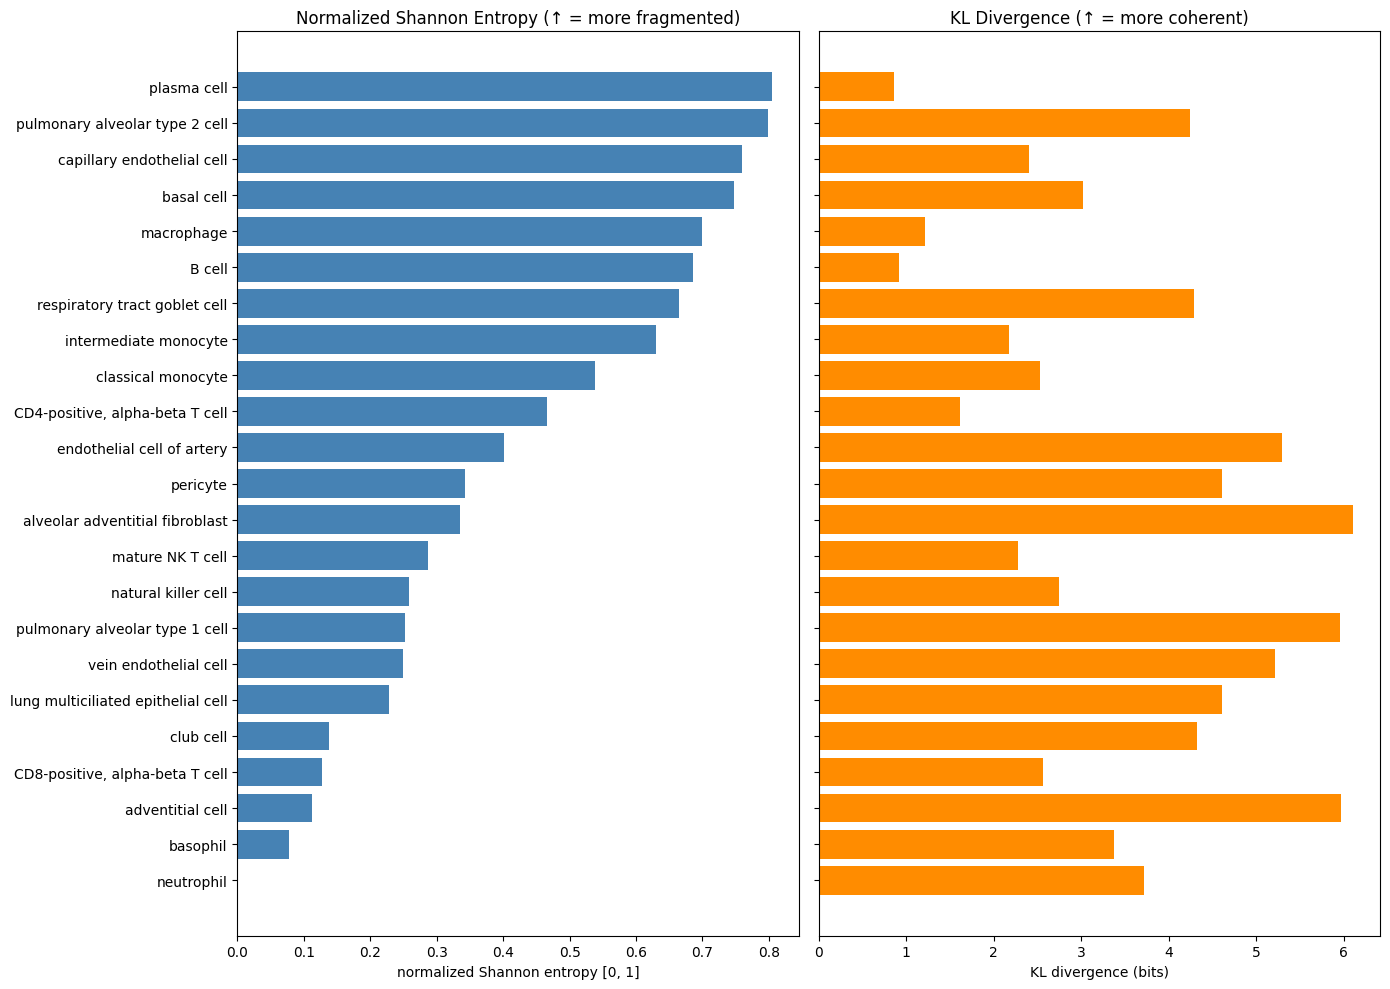

In [ ]:
print("Normalized Shannon Entropy (↑ = more fragmented)")
display(nse_df.round(3))

print("KL Divergence (↑ = more coherent)")
display(kld_df.round(3))

summary_df = pd.DataFrame({
    "n_datasets": nse_df.notna().sum(),
    "normalized_shannon_entropy_mean": nse_df.mean(),
    "kl_divergence_mean": kld_df.mean(),
})
summary_df.index.name = "cell_type"

print("Cross-dataset summary (mean per cell type)")
display(summary_df.sort_values("normalized_shannon_entropy_mean", ascending=False).round(3))

plot_cell_type_metrics(summary_df)

### Inspect cell types on full dataset run

In [2]:
summary_csv = Path("../output/annotation_pipeline/20260509_214237/cell_type_summary.csv")
df = pd.read_csv(summary_csv).dropna(subset=["cell_type"]).set_index("cell_type")
cutoff = 10 # df["n_datasets"].describe()["25%"]
print(f"Filtered cell types appearing in fewer than {cutoff} datasets: {df[df["n_datasets"] < cutoff].index.tolist()}")
df = df[df["n_datasets"] >= cutoff]
df.sort_values("kl_divergence_mean", ascending=False)

Filtered cell types appearing in fewer than 10 datasets: ['endothelial cell', 'smooth muscle cell', 'fibroblast', 'erythrocyte', 'mast cell', 'sebocyte', 'T cell', 'melanocyte', 'naive thymus-derived CD4-positive, alpha-beta T cell', 'hematopoietic precursor cell', 'non-classical monocyte', 'platelet']


,n_datasets,normalized_shannon_entropy_mean,kl_divergence_mean
cell_type,,,
basophil,262,0.087796,5.410267
endothelial cell of lymphatic vessel,218,0.177539,5.091705
neutrophil,73,0.142344,4.961156
bronchial smooth muscle cell,214,0.447193,3.642068
lung multiciliated epithelial cell,415,0.283418,3.615086
pulmonary alveolar type 2 cell,321,0.290455,3.564433
alveolar adventitial fibroblast,214,0.256413,3.518483
adventitial cell,360,0.374394,3.473799
natural killer cell,211,0.172650,3.443761


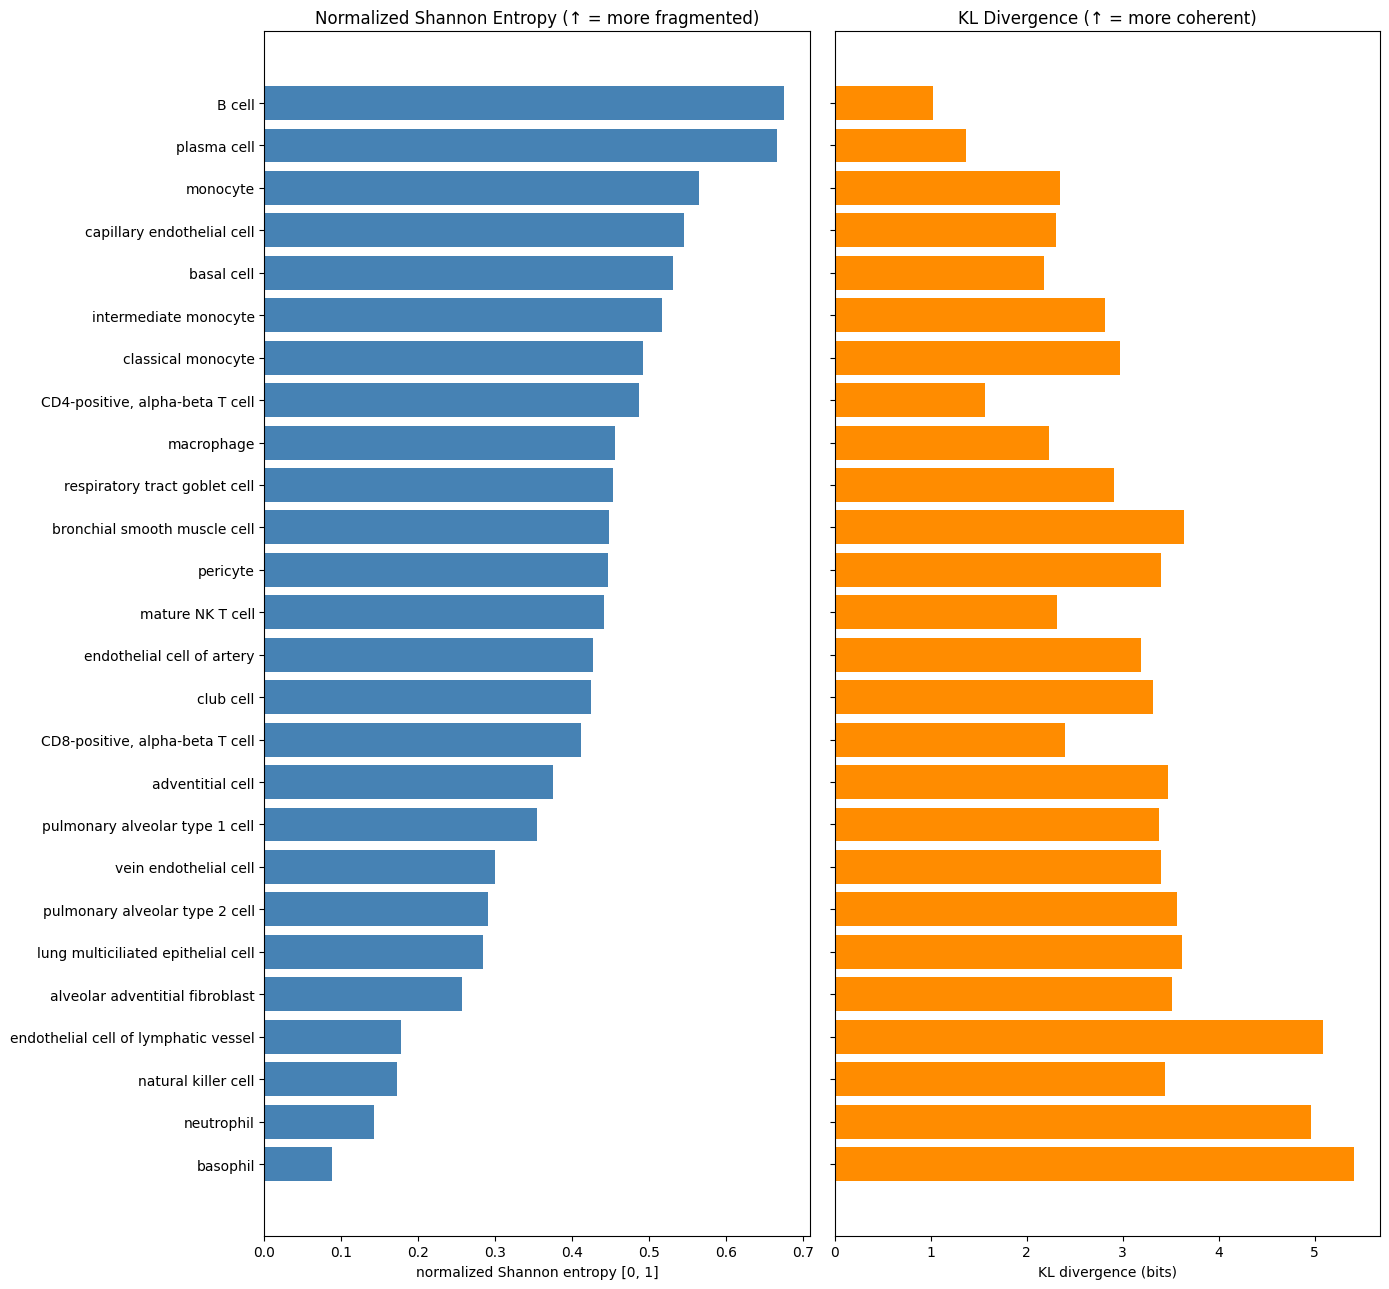

In [3]:
def save_metric_plot(
    summary_df: pd.DataFrame,
    output_path: Path | None = None,
    sort_by: str = "normalized_shannon_entropy_mean",
    dpi: int = 150,
) -> plt.Figure:
    """Save a two-panel horizontal bar chart of NSE and KLD means per cell type.

    The left panel shows normalized Shannon entropy (higher = more fragmented).
    The right panel shows mean KL divergence (higher = more coherent / distinct
    from the global cluster background). Cell types are sorted by sort_by ascending
    so the most fragmented cell type appears at the top.

    Args:
        summary_df: DataFrame produced by build_metric_dataframes, indexed by cell
            type, with columns normalized_shannon_entropy_mean and kl_divergence_mean.
        output_path: Destination path for the PNG file.
        sort_by: Column in summary_df used to sort cell types (default:
            normalized_shannon_entropy_mean).
        dpi: Resolution of the saved image (default: 150).
    """
    sorted_df = summary_df.sort_values(sort_by)
    labels = sorted_df.index.tolist()
    y = np.arange(len(labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, len(labels) * 0.5)))

    ax1.barh(y, sorted_df["normalized_shannon_entropy_mean"], color="steelblue")
    ax1.set_yticks(y)
    ax1.set_yticklabels(labels)
    ax1.set_xlabel("normalized Shannon entropy [0, 1]")
    ax1.set_title("Normalized Shannon Entropy (↑ = more fragmented)")

    ax2.barh(y, sorted_df["kl_divergence_mean"], color="darkorange")
    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlabel("KL divergence (bits)")
    ax2.set_title("KL Divergence (↑ = more coherent)")

    plt.tight_layout()
    if output_path:
        output_path.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi)
    plt.show()


save_metric_plot(df)

# V2

Data from full STATE x leiden cluster count matrix

In [5]:
from shared.repo import REPO_ROOT
from pathlib import Path
import json
import numpy as np
import xarray as xr

CLUSTER_STATS_PATH = (
    REPO_ROOT / "output/cluster_stats/clustered_20260509/cluster_stats.json"
)

with open(CLUSTER_STATS_PATH) as f:
    _data = json.load(f)

samples    = list(_data.keys())
cell_types = sorted({ct for s in _data.values() for ct in s.keys()})
clusters   = sorted(
    {cl for s in _data.values() for ct in s.values() for cl in ct.keys()},
    key=int,
)

arr = np.zeros((len(samples), len(cell_types), len(clusters)), dtype=np.int32)

for i, sample in enumerate(samples):
    for j, cell_type in enumerate(cell_types):
        for k, cluster in enumerate(clusters):
            arr[i, j, k] = _data[sample].get(cell_type, {}).get(cluster, 0)

da = xr.DataArray(
    arr,
    dims=["sample_id", "cell_type", "cluster_id"],
    coords={"sample_id": samples, "cell_type": cell_types, "cluster_id": clusters},
    name="cell_count",
)

da

<xarray.DataArray 'cell_count' (sample_id: 765, cell_type: 39, cluster_id: 106)> Size: 13MB
array([[[    1,     0,     0, ...,     0,     0,     0],
        [    8,   267,     5, ...,     0,     0,     0],
        [ 3468,    10,   903, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[11474,   256,  9593, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[ 6609,  1837,  1609, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
...
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   20,   316,   781, ...,     0,     0,     0],
        [  135,   894,   558, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   86,   196,   191, ...,     0,     0,     0],
        [ 1675,  3196,   633, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]]],
      shape=(765, 39, 106), dtype=int32)
Coordinates:
  * sample_id   (sample_id) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * cell_type   (cell_type) <U52 8kB '' 'B cell' ... 'vein endothelial cell'
  * cluster_id  (cluster_id) <U3 1kB '0' '1' '2' '3' ... '102' '103' '104' '105'

In [27]:
np.unique(np.array(da.cluster_id).astype(int))

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105])